In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import make_smoothing_spline  
from scipy.ndimage import gaussian_filter1d
import numpy as np

CSV_FILE = "/home/andrea/Scrivania/phd/dev/torso-sensor-sa/0D-volumes/circulation_base_limit_cycle.csv"
OUT_CSV_FILE = "/home/andrea/Scrivania/phd/dev/torso-sensor-sa/0D-volumes/circulation_smooth_new.csv"
#CSV_FILE = OUT_CSV_FILE
TIME_START = 78.4
TIME_END = 79.2

INTERPOLATION_METHOD = ""
SAVGOL_WINDOW = 11  # Must be odd
SAVGOL_POLY = 3     # Cubic smoothing
SPLINE_SMOOTH_FACTOR = 1.5  # 's' parameter. 
                            # 0 = exact fit (noisy), High = very smooth (loss of detail).
                            # Start small (e.g., len(data)*var) or tune manually.
SIGMA_VAL = 1.5 

In [2]:
df = pd.read_csv(CSV_FILE)
df.columns

df = df[(df['time'] >= TIME_START) & (df['time'] <= TIME_END)].copy()


In [15]:
# Extract Raw Data
raw_times = df['time'].values.copy()
raw_volumes = df['VLV'].values.copy() 

print(f"Datum not periodic, enforcing it. V[0] : {raw_volumes[0]}, V[-1] : {raw_volumes[-1]}")


# interpolated acc
dt_raw = np.mean(np.diff(raw_times))
acc_interp = np.gradient(np.gradient(raw_volumes, dt_raw), dt_raw)

print(f"Time steps found: {len(raw_times)}")

# Ensure periodicity
raw_volumes[-1] = raw_volumes[0]

# --- APPLY METHOD ---
print(f"--- Applying Method: {INTERPOLATION_METHOD} (On Original Grid) ---")


# 1. SavGol (Your current settings)
savgol_volumes = savgol_filter(raw_volumes, window_length=11, polyorder=3)

# Calculate acceleration for SavGol
dt = np.mean(np.diff(raw_times))
vel_savgol = np.gradient(savgol_volumes, dt)
acc_savgol = np.gradient(vel_savgol, dt)

# Cubic spline
cs = CubicSpline(raw_times, raw_volumes)
cs_volumes = cs(raw_times, nu=0)
# Analytic derivative (nu=2 for acceleration)
acc_cspline = cs(raw_times, nu=2)

# Smoothing Spline
# spl = UnivariateSpline(raw_times, raw_volumes, s=0.05, k=3) 
# spl_volumes = spl(raw_times)
# # Spline allows analytic derivatives (cleaner)
# acc_sspline = spl.derivative(n=2)(raw_times) 

# 3. Gaussian Filter (NEW - HIGHLY RECOMMENDED)
# This acts like "viscoelasticity". It keeps the peak but rounds the tip.
# sigma=1.0 is sharp, sigma=2.0 is smooth.
gauss_volumes = gaussian_filter1d(raw_volumes, sigma=SIGMA_VAL)
vel_gauss = np.gradient(gauss_volumes, dt)
acc_gauss = np.gradient(vel_gauss, dt)

smspl = make_smoothing_spline(raw_times, raw_volumes, lam=5e-7)
smspl_volumes = smspl(raw_times)
acc_smspl = smspl(raw_times, nu=2)  # nu=2 calculates the 2nd derivative directly


Datum not periodic, enforcing it. V[0] : 157.77811241, V[-1] : 157.41085425
Time steps found: 160
--- Applying Method:  (On Original Grid) ---


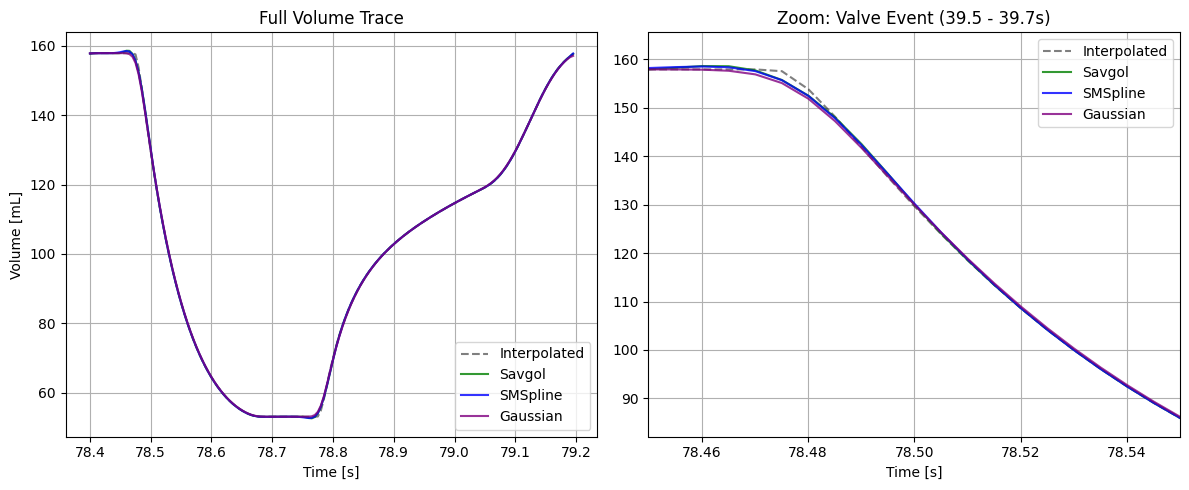

In [10]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT PLOT: Full Data ---
ax1.plot(raw_times, raw_volumes, color='black', linestyle='--', alpha=0.5, label='Interpolated')
ax1.plot(raw_times, savgol_volumes, color='green', alpha=0.8, label='Savgol')
#ax1.plot(raw_times, spl_volumes, color='red', alpha=0.8, label='SSpline')
ax1.plot(raw_times, smspl_volumes, color='blue', alpha=0.8, label='SMSpline')
ax1.plot(raw_times, gauss_volumes, color='purple', alpha=0.8, label='Gaussian')

ax1.set_title("Full Volume Trace")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Volume [mL]")
ax1.legend()
ax1.grid(True)

# --- RIGHT PLOT: Zoomed Interval (39.5 - 39.7) ---
ax2.plot(raw_times, raw_volumes, color='black', linestyle='--', alpha=0.5, label='Interpolated')
ax2.plot(raw_times, savgol_volumes, color='green', alpha=0.8, label='Savgol')
ax2.plot(raw_times, smspl_volumes, color='blue', alpha=0.8, label='SMSpline')
#ax2.plot(raw_times, spl_volumes, color='red', alpha=0.8, label='SSpline')
ax2.plot(raw_times, gauss_volumes, color='purple', alpha=0.8, label='Gaussian')

# Set the limits for the zoom
XDOWN = 78.45
XUP = 78.55
ax2.set_xlim(XDOWN, XUP)

# Optional: Auto-scale Y-axis for the zoomed region
# This finds the min/max of the data *only* within the zoom window
mask = (raw_times >= XDOWN) & (raw_times <= XUP)
if any(mask):
    y_min = min(raw_volumes[mask].min(), savgol_volumes[mask].min(), smspl_volumes[mask].min(), gauss_volumes[mask].min())
    y_max = max(raw_volumes[mask].max(), savgol_volumes[mask].max(), smspl_volumes[mask].max(), gauss_volumes[mask].max())
    # Add a small padding (e.g. 10%)
    padding = (y_max - y_min) * 0.1
    ax2.set_ylim(y_min - padding, y_max + padding)

ax2.set_title("Zoom: Valve Event (39.5 - 39.7s)")
ax2.set_xlabel("Time [s]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

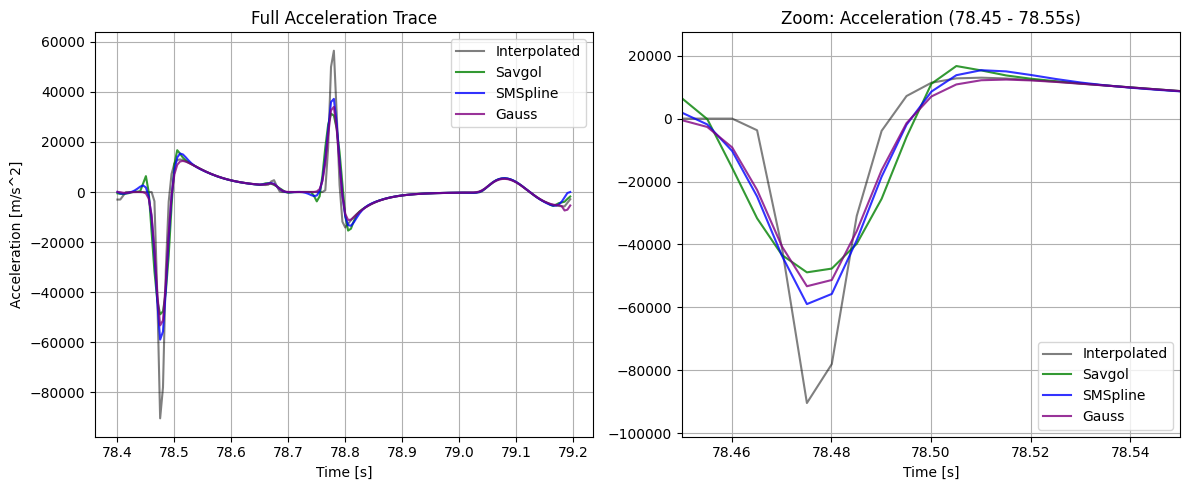

In [16]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT PLOT: Full Data ---
ax1.plot(raw_times, acc_interp, color='black', alpha=0.5, label='Interpolated')
ax1.plot(raw_times, acc_savgol, color='green', alpha=0.8, label='Savgol')
ax1.plot(raw_times, acc_smspl, color='blue', alpha=0.8, label='SMSpline')
#ax1.plot(raw_times, acc_sspline, color='red', alpha=0.8, label='SSpline')
ax1.plot(raw_times, acc_gauss, color='purple', alpha=0.8, label='Gauss')
ax1.set_title("Full Acceleration Trace")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Acceleration [m/s^2]")  # Assuming acceleration units
ax1.legend()
ax1.grid(True)

# --- RIGHT PLOT: Zoomed Interval ---
# Set the limits for the zoom
XDOWN = 78.45
XUP = 78.55

ax2.plot(raw_times, acc_interp, color='black', alpha=0.5, label='Interpolated')
ax2.plot(raw_times, acc_savgol, color='green', alpha=0.8, label='Savgol')
ax2.plot(raw_times, acc_smspl, color='blue', alpha=0.8, label='SMSpline')
#ax2.plot(raw_times, acc_sspline, color='red', alpha=0.8, label='SSpline')
ax2.plot(raw_times, acc_gauss, color='purple', alpha=0.8, label='Gauss')

ax2.set_xlim(XDOWN, XUP)

# Optional: Auto-scale Y-axis for the zoomed region
# This finds the min/max of the data *only* within the zoom window
mask = (raw_times >= XDOWN) & (raw_times <= XUP)
if any(mask):
    # Check if arrays are not empty to avoid errors
    vals_interp = acc_interp[mask] if len(acc_interp) > 0 else []
    vals_savgol = acc_savgol[mask] if len(acc_savgol) > 0 else []
    #vals_sspline = acc_sspline[mask] if len(acc_sspline) > 0 else []
    
    # Calculate min/max across all three arrays in the masked region
    # Using np.min/np.max is safer if they are numpy arrays
    current_mins = []
    current_maxs = []
    
    if len(vals_interp) > 0:
        current_mins.append(np.min(vals_interp))
        current_maxs.append(np.max(vals_interp))
    if len(vals_savgol) > 0:
        current_mins.append(np.min(vals_savgol))
        current_maxs.append(np.max(vals_savgol))
    # if len(vals_sspline) > 0:
    #     current_mins.append(np.min(vals_sspline))
    #     current_maxs.append(np.max(vals_sspline))
        
    if current_mins:
        y_min = min(current_mins)
        y_max = max(current_maxs)
        # Add a small padding (e.g. 10%)
        padding = (y_max - y_min) * 0.1 if y_max != y_min else 1.0
        ax2.set_ylim(y_min - padding, y_max + padding)

ax2.set_title(f"Zoom: Acceleration ({XDOWN} - {XUP}s)")
ax2.set_xlabel("Time [s]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


### Analysis of periodicity effect

In [80]:
# Extract Raw Data
raw_times = df['time'].values.copy()
raw_volumes = df['VLV'].values.copy()
print(f"Datum not periodic, enforcing it. V[0] : {raw_volumes[0]}, V[-1] : {raw_volumes[-1]}")

# Non Periodic interpolate
vlv_smooth_non_periodic = gaussian_filter1d(raw_volumes, sigma=3, mode='wrap')

# Periodic interpolate
raw_volumes[-1] = raw_volumes[0]
v_pre_smoothed = gaussian_filter1d(v_pre_smoothed, sigma=3, mode='wrap')
v_pre_smoothed[-1] = v_pre_smoothed[0]
spline = CubicSpline(raw_times, v_pre_smoothed, bc_type='periodic')
#num_frames = 800
#fine_times = np.linspace(raw_times[0], raw_times[-1], num_frames)
vlv_smooth_periodic = spline(raw_times)

# --- 4. VERIFY ACCELERATION ---
# periodic
dt_raw = np.mean(np.diff(raw_times))
acc_smooth = np.gradient(np.gradient(vlv_smooth_periodic, dt_raw), dt_raw)
print(f"New Max Accel: {np.max(np.abs(acc_smooth)):.2f} mL/s^2")

# non periodic
dt_raw = np.mean(np.diff(raw_times))
acc_interp_no_periodic = np.gradient(np.gradient(vlv_smooth_non_periodic, dt_raw), dt_raw)
print(f"Non Periodic Max Accel: {np.max(np.abs(acc_interp_no_periodic)):.2f} mL/s^2")
#print(f"a_nop[0] : {acc_interp_no_periodic[0]}, a_nop[-1] : {acc_interp_no_periodic[-1]}")

Datum not periodic, enforcing it. V[0] : 157.77811241, V[-1] : 157.41085425
New Max Accel: 14583.97 mL/s^2
Non Periodic Max Accel: 29818.65 mL/s^2


In [77]:
print(vlv_smooth_periodic[0], vlv_smooth_periodic[-1])
print(vlv_smooth_non_periodic[0], vlv_smooth_non_periodic[-1])

156.74532581653438 156.74532581653438
157.58272088710436 157.23576963085557


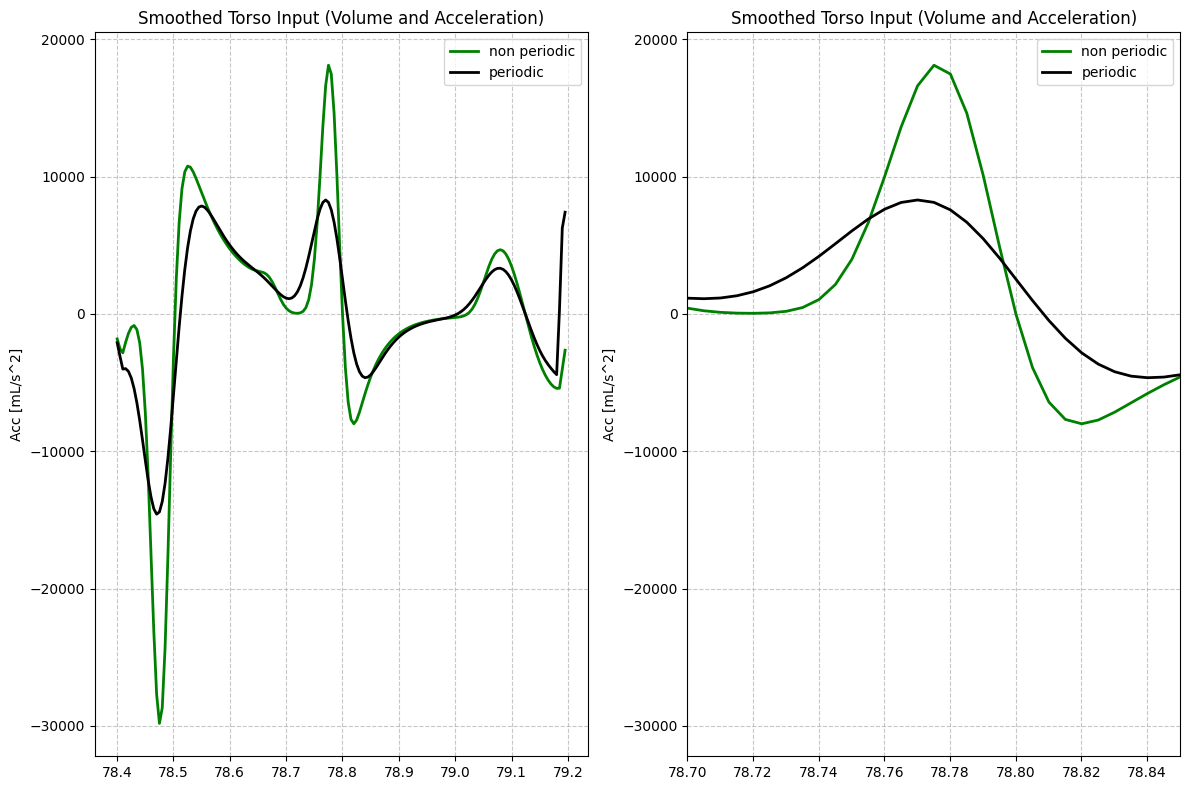

In [81]:
# --- 2. CREATE THE PLOT ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Plot Smoothed Volume (VLV)
# Note: Use the column name you actually saved (e.g., 'VLV' or 'VLV_smooth')
ax1.plot(raw_times, acc_interp_no_periodic, color='green', linewidth=2, label="non periodic")
ax1.plot(raw_times, acc_smooth, color='black', linewidth=2, label="periodic")
ax1.set_ylabel("Acc [mL/s^2]")
ax1.set_title("Smoothed Torso Input (Volume and Acceleration)")
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Resulting Acceleration (The SCG Signal)
# This is where your MC, AO, AC, and MO points live
ax2.plot(raw_times, acc_interp_no_periodic, color='green', linewidth=2, label="non periodic")
ax2.plot(raw_times, acc_smooth, color='black', linewidth=2, label="periodic")
ax2.set_ylabel("Acc [mL/s^2]")
ax2.set_title("Smoothed Torso Input (Volume and Acceleration)")
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# --- 3. ZOOM INTO ONE HEARTBEAT ---
# Adjust these values based on your specific cycle timing
ax2.set_xlim(78.7, 78.85) 

plt.tight_layout()
plt.show()

## Save new circulation.csv

In [13]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline

df_raw = pd.read_csv(CSV_FILE)

# Sort by time to ensure a continuous signal
df_raw = df_raw.sort_values(by='time').reset_index(drop=True)

# Filter for the specific time range you want (e.g., 39.2 to 40.0)
df_window = df_raw[(df_raw['time'] >= TIME_START) & (df_raw['time'] <= TIME_END)].copy()

if df_window.empty:
    print(f"Error: No data found between {TIME_START} and {TIME_END}")
    sys.exit(1)

raw_times = df_window['time'].values.copy()
raw_volumes = df_window['VLV'].values.copy()

print(raw_times.size)

# --- 2. ENFORCE PERIODICITY & GENERATE SPLINE ---
# Match values at boundaries (C0)
# raw_volumes[-1] = raw_volumes[0]
# spline = CubicSpline(raw_times, raw_volumes, bc_type='periodic')
# num_frames = 100
# fine_times = np.linspace(raw_times[0], raw_times[-1], num_frames)
# #fine_times = raw_times
# fine_volumes = spline(fine_times)

## just to reframe
num_frames = 100
indices = np.linspace(0, len(raw_volumes) - 1, num_frames).astype(int)
fine_times = raw_times[indices]
fine_volumes = raw_volumes[indices]
print(fine_times.size)


# --- 4. DIAGNOSTICS ---
dt_fine = np.mean(np.diff(raw_times))
acc_fine = np.gradient(np.gradient(fine_volumes, dt_fine), dt_fine)

print(f"Time Range: {fine_times[0]:.2f}s to {fine_times[-1]:.2f}s")
print(f"Max Acceleration (Spline): {np.max(np.abs(acc_fine)):.2f} mL/s^2")

# --- 5. SAVE CLEAN OUTPUT ---
df_out = pd.DataFrame({
    'time': fine_times,
    'VLV': fine_volumes
})

OUT_CSV_FILE = "/home/andrea/Scrivania/phd/dev/torso-sensor-sa/0D-volumes/circulation_reduced.csv"
df_out.to_csv(OUT_CSV_FILE, index=False)

320
100
Time Range: 78.40s to 79.20s
Max Acceleration (Spline): 562299.70 mL/s^2


#### Check unfiform dt

In [2]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline

df_raw = pd.read_csv(CSV_FILE)

# Sort by time to ensure a continuous signal
df_raw = df_raw.sort_values(by='time').reset_index(drop=True)

# Filter for the specific time range you want (e.g., 39.2 to 40.0)
df_window = df_raw[(df_raw['time'] >= TIME_START) & (df_raw['time'] <= TIME_END)].copy()

if df_window.empty:
    print(f"Error: No data found between {TIME_START} and {TIME_END}")
    sys.exit(1)

raw_times = df_window['time'].values.copy()
raw_volumes = df_window['VLV'].values.copy()

In [3]:
# 1. Calculate the difference between every consecutive time step
delta_ts = np.diff(raw_times)

# 2. Get the first delta_t to compare against the rest
expected_dt = delta_ts[0]

# 3. Check if all delta_ts are essentially equal to the first one
# (atol=1e-6 means it ignores differences smaller than 0.000001)
is_uniform = np.allclose(delta_ts, expected_dt, atol=1e-6)

if is_uniform:
    print(f"SUCCESS: delta_t is uniform. Constant dt = {expected_dt:.6f}s")
else:
    print(f"WARNING: delta_t is NOT uniform!")
    print(f"Minimum dt: {delta_ts.min():.6f}s")
    print(f"Maximum dt: {delta_ts.max():.6f}s")

SUCCESS: delta_t is uniform. Constant dt = 0.002500s


In [6]:
df_raw = pd.read_csv(OUT_CSV_FILE)

r_times = df_window['time'].values.copy()
r_volumes = df_window['VLV'].values.copy()

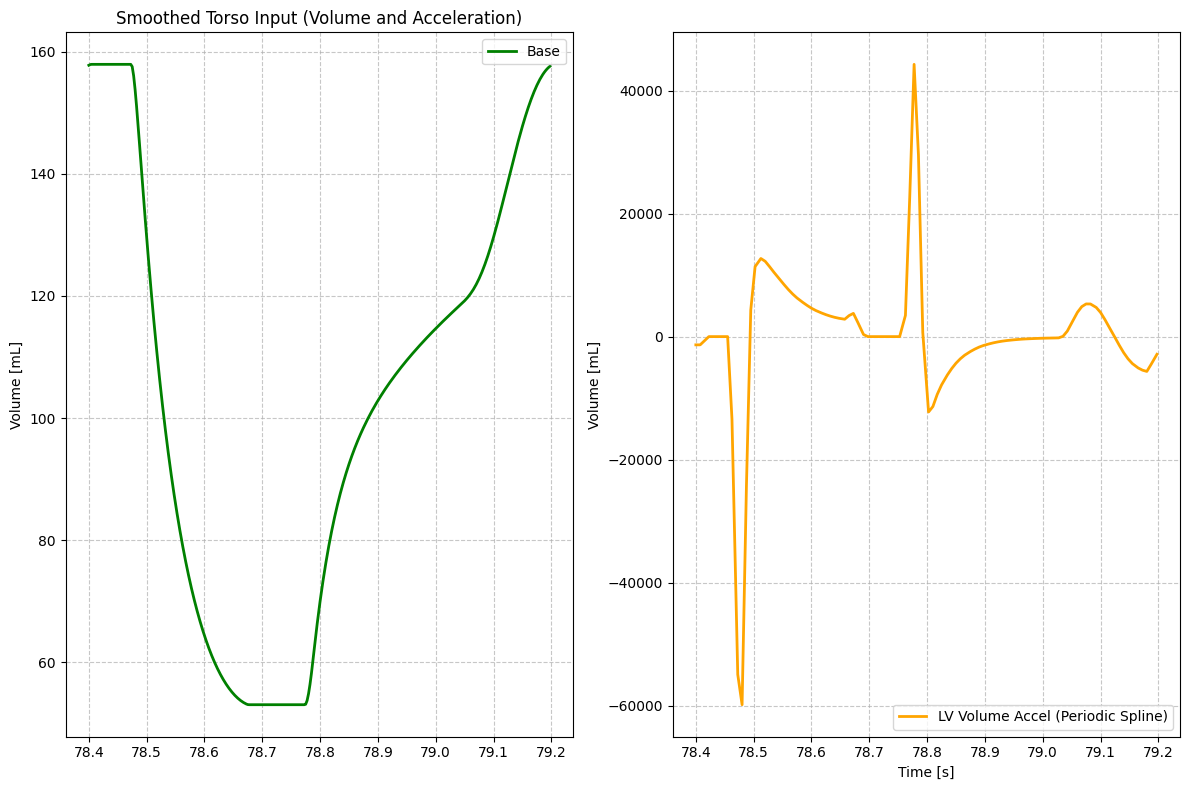

In [8]:
# --- 2. CREATE THE PLOT ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# Plot Smoothed Volume (VLV)
# Note: Use the column name you actually saved (e.g., 'VLV' or 'VLV_smooth')
ax1.plot(r_times, r_volumes, color='green', linewidth=2, label="Base")
#ax1.plot(fine_times, fine_volumes, color='black', linewidth=2, label="New")

ax1.set_ylabel("Volume [mL]")
ax1.set_title("Smoothed Torso Input (Volume and Acceleration)")
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()
#ax1.set_xlim(78.7, 78.8) 


# Calculate the first and second derivatives using the time array for scaling
velocity = np.gradient(df_out["VLV"], df_out["time"])
acceleration = np.gradient(velocity, df_out["time"])

# Plotting the corrected acceleration
ax2.plot(
    df_out["time"], 
    acceleration, 
    color='orange', 
    linewidth=2, 
    label="LV Volume Accel (Periodic Spline)"
)
ax2.set_ylabel("Volume [mL]")
ax2.set_xlabel("Time [s]")
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# --- 3. ZOOM INTO ONE HEARTBEAT ---
# Adjust these values based on your specific cycle timing
#ax2.set_xlim(79.1, 79.2) 
#ax2.set_ylim(120, 141) 


plt.tight_layout()
plt.show()

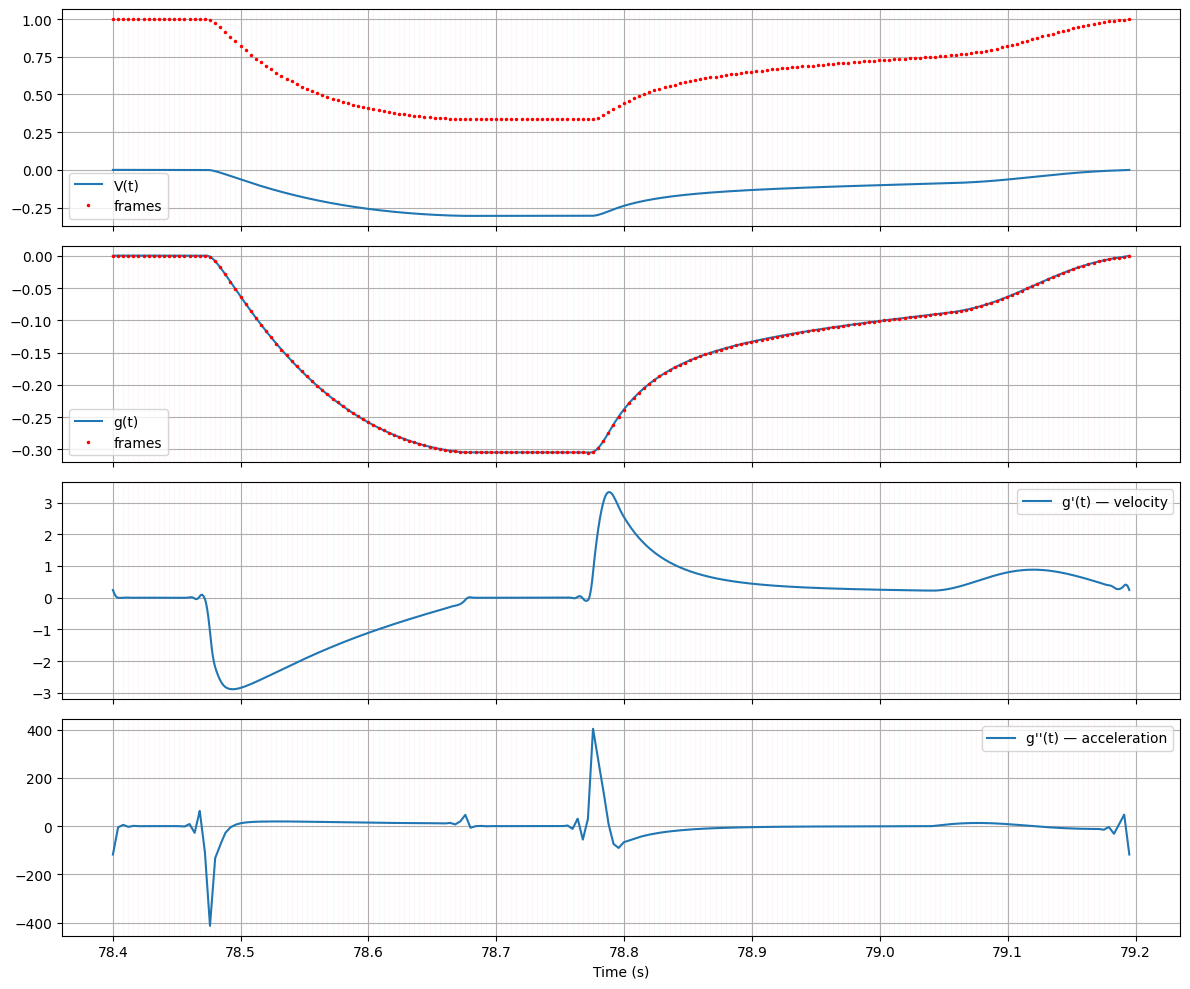

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Load processed CSV (500 frames)
df = pd.read_csv(OUT_CSV_FILE)
times  = df['time'].values
volumes = df['VLV'].values

V_ref = volumes[0]

# Compute g at the 500 frame points
g_values = np.cbrt(volumes / V_ref) - 1.0

# Build spline on g directly
g_spline = CubicSpline(times, g_values, bc_type='periodic')

t_fine = np.linspace(times[0], times[-1], 10000)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_fine, g_spline(t_fine, 0), label='V(t)')
axes[0].plot(times, volumes / V_ref,  'r.', markersize=3, label='frames')

axes[1].plot(t_fine, g_spline(t_fine, 0), label='g(t)')
axes[1].plot(times, g_values, 'r.', markersize=3, label='frames')

axes[2].plot(t_fine, g_spline(t_fine, 1), label="g'(t) — velocity")

axes[3].plot(t_fine, g_spline(t_fine, 2), label="g''(t) — acceleration")

# Mark VTK frame boundaries
for ax in axes:
    for tf in times:
        ax.axvline(tf, color='red', alpha=0.05, linewidth=0.5)
    ax.legend()
    ax.grid(True)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()